In [15]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install imbalanced-learn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd

# Define the file path
file_path = 'D:/DSGP project/DSGP/datasets/raw/Crop_and_fertilizer_dataset.csv'

# Load the dataset
data = pd.read_csv(file_path)

# Display dataset information
print("First few rows of the dataset:")
print(data.head())

print("\nDataset information:")
print(data.info())


First few rows of the dataset:
  District_Name Soil_color  Nitrogen  Phosphorus  Potassium   pH  Rainfall  \
0      Kolhapur      Black        75          50        100  6.5      1000   
1      Kolhapur      Black        80          50        100  6.5      1000   
2      Kolhapur      Black        85          50        100  6.5      1000   
3      Kolhapur      Black        90          50        100  6.5      1000   
4      Kolhapur      Black        95          50        100  6.5      1000   

   Temperature       Crop Fertilizer                          Link  
0           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
1           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
2           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
3           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
4           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 

In [17]:
# Filter the dataset for rice-related data only
rice_data = data[data['Crop'].str.lower() == 'rice']

# Drop irrelevant columns
rice_data = rice_data.drop(columns=['District_Name', 'Soil_color', 'Link', 'Crop'])

# Check for missing values
missing_values = rice_data.isnull().sum()

# Check for duplicate rows
duplicates = rice_data.duplicated().sum()

print(rice_data.head())
print(rice_data.shape)




     Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature Fertilizer
624        20          15         20  5.5       700           25       Urea
625        25          15         20  5.5       700           25       Urea
626        30          15         20  5.5       700           25       Urea
627        20          20         25  6.0       800           30       Urea
628        25          20         25  6.0       800           30       Urea
(309, 7)


In [18]:
# Encode the target variable (Fertilizer)
rice_data['Fertilizer_encoded'] = rice_data['Fertilizer'].astype('category').cat.codes

# Display the mapping of fertilizer categories
fertilizer_mapping = dict(enumerate(rice_data['Fertilizer'].astype('category').cat.categories))

fertilizer_mapping

{0: '50:26:26 NPK', 1: 'Urea'}

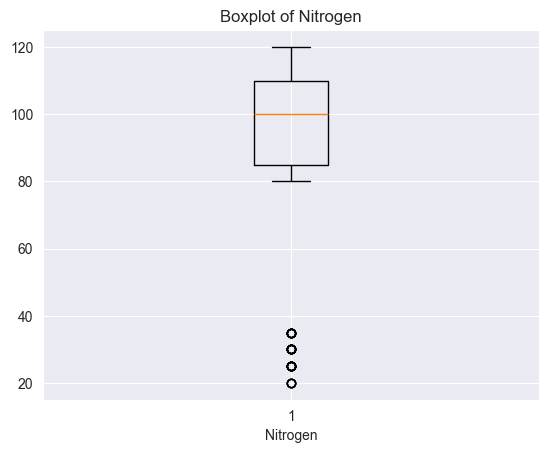

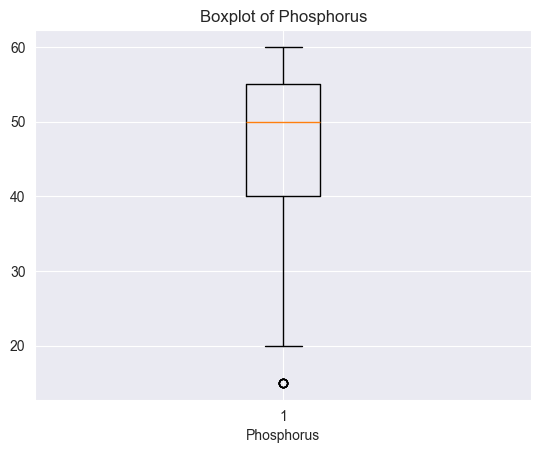

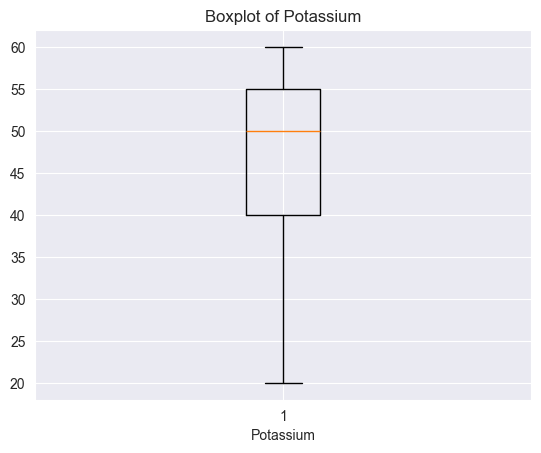

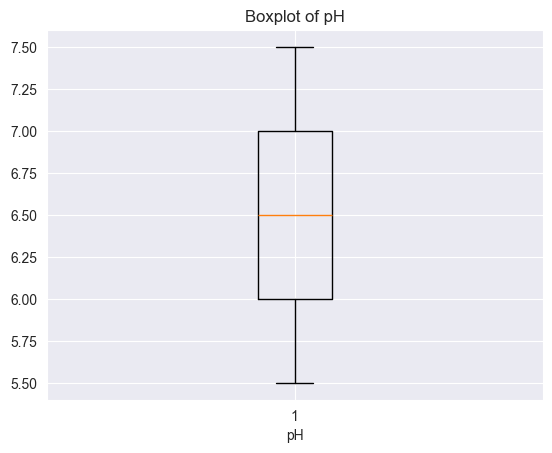

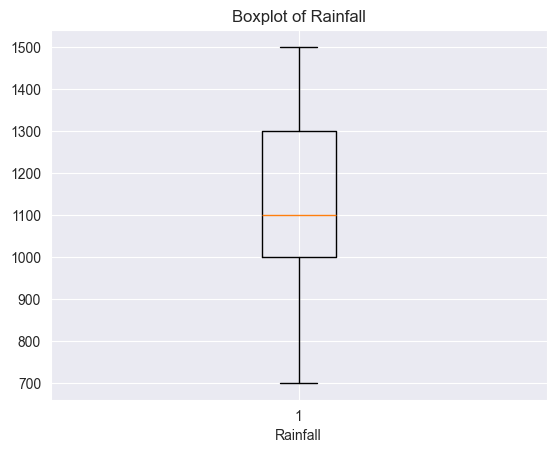

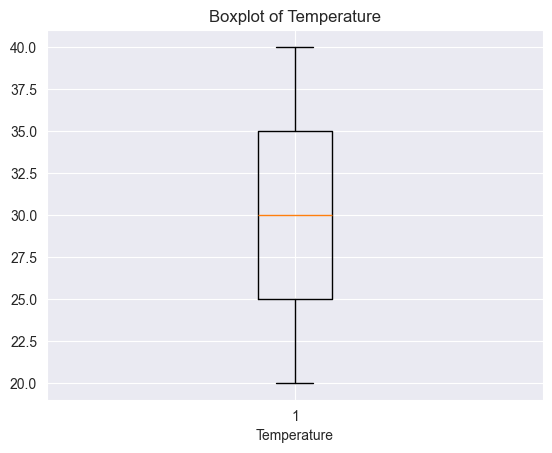

In [19]:
import matplotlib.pyplot as plt

# Check for outliers using boxplots
numerical_features = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']

# Plot boxplots for each numerical feature to identify outliers
for feature in numerical_features:
    plt.figure()
    plt.boxplot(rice_data[feature])
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.show()




In [20]:
# Function to remove outliers using the IQR method
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Removing outliers
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Apply the function to numerical features
numerical_features = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']
rice_data_cleaned = remove_outliers_iqr(rice_data, numerical_features)

# Display the cleaned data after outlier removal
print("Rice Dataset After Removing Outliers\n", rice_data_cleaned)


Rice Dataset After Removing Outliers
       Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature Fertilizer  \
2167        80          40         40  6.0      1000           25       Urea   
2168        85          40         40  6.0      1000           25       Urea   
2169        90          40         40  6.0      1000           25       Urea   
2170        95          40         40  6.0      1000           25       Urea   
2171       100          40         40  6.0      1000           25       Urea   
...        ...         ...        ...  ...       ...          ...        ...   
4074       100          60         55  6.5       900           35       Urea   
4075       105          60         55  6.5       900           35       Urea   
4076       110          60         55  6.5       900           35       Urea   
4077       115          60         55  6.5       900           35       Urea   
4078       120          60         55  6.5       900           35       Urea   

 

In [21]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Features and target
X = rice_data_cleaned[['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']]
y = rice_data_cleaned['Fertilizer_encoded']

# Split the data before applying Min-Max Scaling (best practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE on the training set only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
from collections import Counter
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))


Before SMOTE: Counter({1: 132, 0: 84})
After SMOTE: Counter({1: 132, 0: 132})


In [22]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the Min-Max Scaler
scaler = MinMaxScaler()

# Apply Min-Max Scaling to the training data
X_train_scaled = scaler.fit_transform(X_train_smote)

# Apply the same transformation to the test data
X_test_scaled = scaler.transform(X_test)

# Check the scaled data (optional)
import pandas as pd
scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("Min-Max Scaled Training Data\n", scaled_df)


Min-Max Scaled Training Data
      Nitrogen  Phosphorus  Potassium    pH  Rainfall  Temperature
0       0.125        1.00       1.00  0.25     0.875         0.50
1       0.875        0.50       1.00  0.25     0.375         0.25
2       0.750        0.25       0.00  0.50     0.750         0.25
3       0.875        0.50       0.00  0.50     1.000         0.75
4       0.625        0.00       0.50  0.75     0.875         0.50
..        ...         ...        ...   ...       ...          ...
259     0.500        1.00       0.00  0.50     0.750         0.25
260     0.450        0.25       0.50  0.75     0.375         0.25
261     0.525        0.00       0.25  0.50     1.000         0.75
262     0.475        0.70       0.25  0.75     0.375         0.25
263     0.150        1.00       0.00  0.50     0.750         0.25

[264 rows x 6 columns]


In [23]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Function to add maximized Gaussian noise
def add_gaussian_noise(data, mean=0, std=0.2):  # Increased std to 0.2
    noise = np.random.normal(mean, std, data.shape)
    noisy_data = data + noise
    return noisy_data

# Add maximum noise to the training data
X_train_noisy_max = add_gaussian_noise(X_train_scaled, std=0.2)

# Train the Random Forest Classifier with maximized noisy data
rf_model_noisy_max = RandomForestClassifier(random_state=42)
rf_model_noisy_max.fit(X_train_noisy_max, y_train_smote)

# Predictions on the test set
y_pred_rf_noisy_max_test = rf_model_noisy_max.predict(X_test_scaled)
y_pred_rf_noisy_max_train = rf_model_noisy_max.predict(X_train_noisy_max)

# Evaluate the model on the test set
accuracy_rf_noisy_max_test = accuracy_score(y_test, y_pred_rf_noisy_max_test)
report_rf_noisy_max_test = classification_report(y_test, y_pred_rf_noisy_max_test)
conf_matrix_rf_noisy_max_test = confusion_matrix(y_test, y_pred_rf_noisy_max_test)

# Evaluate the model on the training set
accuracy_rf_noisy_max_train = accuracy_score(y_train_smote, y_pred_rf_noisy_max_train)
report_rf_noisy_max_train = classification_report(y_train_smote, y_pred_rf_noisy_max_train)
conf_matrix_rf_noisy_max_train = confusion_matrix(y_train_smote, y_pred_rf_noisy_max_train)

# Display the results for the test set
print("Random Forest Model Performance with Maximum Noise (Test Set):")
print(f"Accuracy: {accuracy_rf_noisy_max_test:.4f}")
print("\nClassification Report:\n", report_rf_noisy_max_test)
print("Confusion Matrix:\n", conf_matrix_rf_noisy_max_test)

# Display the results for the training set
print("\nRandom Forest Model Performance with Maximum Noise (Training Set):")
print(f"Accuracy: {accuracy_rf_noisy_max_train:.4f}")
print("\nClassification Report:\n", report_rf_noisy_max_train)
print("Confusion Matrix:\n", conf_matrix_rf_noisy_max_train)


Random Forest Model Performance with Maximum Noise (Test Set):
Accuracy: 0.6852

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.86      0.68        21
           1       0.86      0.58      0.69        33

    accuracy                           0.69        54
   macro avg       0.71      0.72      0.69        54
weighted avg       0.75      0.69      0.69        54

Confusion Matrix:
 [[18  3]
 [14 19]]

Random Forest Model Performance with Maximum Noise (Training Set):
Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       132
           1       1.00      1.00      1.00       132

    accuracy                           1.00       264
   macro avg       1.00      1.00      1.00       264
weighted avg       1.00      1.00      1.00       264

Confusion Matrix:
 [[132   0]
 [  0 132]]


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Regularized Random Forest
rf_model_regularized = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=5,           # Limit tree depth to prevent overfitting
    min_samples_split=10,  # Minimum samples required to split a node
    min_samples_leaf=5,    # Minimum samples required at a leaf node
    max_features='sqrt',   # Limit the number of features considered for splitting
    random_state=42
)

# Train the model
rf_model_regularized.fit(X_train_scaled, y_train_smote)

# Predictions
y_pred_rf_test = rf_model_regularized.predict(X_test_scaled)
y_pred_rf_train = rf_model_regularized.predict(X_train_scaled)

# Evaluation
accuracy_rf_test = accuracy_score(y_test, y_pred_rf_test)
report_rf_test = classification_report(y_test, y_pred_rf_test)
conf_matrix_rf_test = confusion_matrix(y_test, y_pred_rf_test)

accuracy_rf_train = accuracy_score(y_train_smote, y_pred_rf_train)
report_rf_train = classification_report(y_train_smote, y_pred_rf_train)
conf_matrix_rf_train = confusion_matrix(y_train_smote, y_pred_rf_train)

# Display results
print("Random Forest Model Performance (Test Set):")
print(f"Accuracy: {accuracy_rf_test:.4f}")
print("\nClassification Report:\n", report_rf_test)
print("Confusion Matrix:\n", conf_matrix_rf_test)

print("\nRandom Forest Model Performance (Training Set):")
print(f"Accuracy: {accuracy_rf_train:.4f}")
print("\nClassification Report:\n", report_rf_train)
print("Confusion Matrix:\n", conf_matrix_rf_train)


Random Forest Model Performance (Test Set):
Accuracy: 0.9074

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.86      0.88        21
           1       0.91      0.94      0.93        33

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54

Confusion Matrix:
 [[18  3]
 [ 2 31]]

Random Forest Model Performance (Training Set):
Accuracy: 0.9508

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95       132
           1       0.93      0.97      0.95       132

    accuracy                           0.95       264
   macro avg       0.95      0.95      0.95       264
weighted avg       0.95      0.95      0.95       264

Confusion Matrix:
 [[123   9]
 [  4 128]]


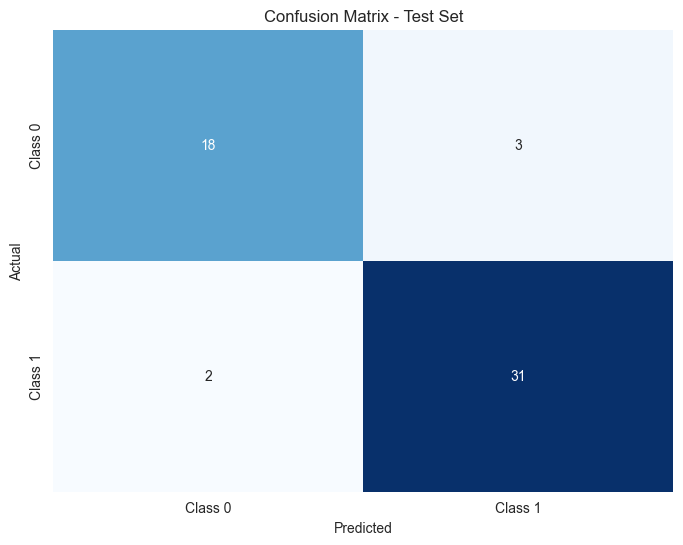

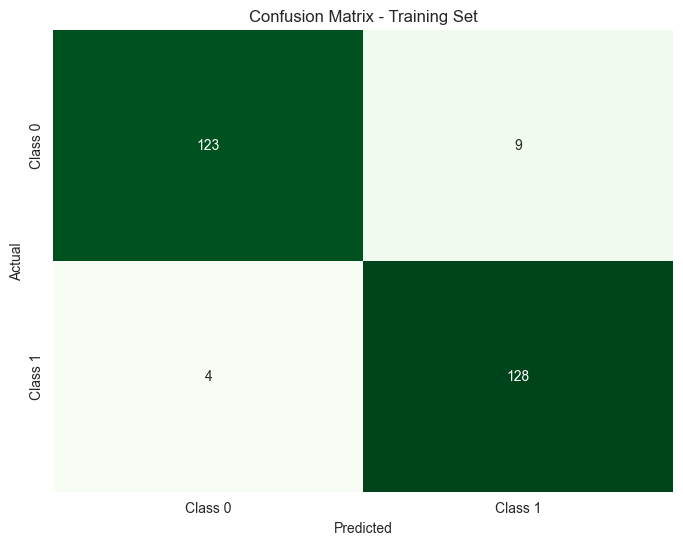

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Given confusion matrices
conf_matrix_rf_test = [[18, 3], [2, 31]]
conf_matrix_rf_train = [[123, 9], [4, 128]]

# Plotting the confusion matrix for the test set
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plotting the confusion matrix for the training set
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf_train, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - Training Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [26]:
%pip install joblib


Note: you may need to restart the kernel to use updated packages.


In [35]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model_regularized, 'D:/DSGP project/DSGP/backend/models/fertilizer/rf_model.joblib')

# Save the scaler (important for preprocessing user inputs)
joblib.dump(scaler, 'D:/DSGP project/DSGP/backend/models/fertilizer/scaler.pkl')

print("Model and Scaler saved successfully")



Model and Scaler saved successfully


In [34]:
import joblib

# Load the Random Forest model and the scaler
rf_model = joblib.load('D:/DSGP project/DSGP/backend/models/fertilizer/rf_model.joblib')
scaler = joblib.load('D:/DSGP project/DSGP/backend/models/fertilizer/scaler.pkl')

# Fertilizer mapping (0 = NPK, 1 = Urea)
fertilizer_mapping = {0: '50:26:26 NPK', 1: 'Urea'}

def predict_fertilizer_rf(N, P, K, pH, Rainfall, Temperature):
    # Prepare input data
    user_input = [[N, P, K, pH, Rainfall, Temperature]]

    # Scale the input data
    scaled_input = scaler.transform(user_input)

    # Predict the fertilizer
    predicted_class = rf_model.predict(scaled_input)[0]
    recommended_fertilizer = fertilizer_mapping[predicted_class]

    return recommended_fertilizer

# User input
N = float(input("Enter Nitrogen (N) level: "))
P = float(input("Enter Phosphorus (P) level: "))
K = float(input("Enter Potassium (K) level: "))
pH = float(input("Enter pH level: "))
Rainfall = float(input("Enter Rainfall (mm): "))
Temperature = float(input("Enter Temperature (°C): "))

# Predict and display the fertilizer recommendation
fertilizer = predict_fertilizer_rf(N, P, K, pH, Rainfall, Temperature)
print(f"\nRecommended Fertilizer: {fertilizer}")



Recommended Fertilizer: 50:26:26 NPK


D:\DSGP project\DSGP\backend\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
